In [40]:
import scipy as sp
from scipy.special import jv, hankel2, yv, spherical_jn, spherical_yn
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones

In [41]:
def hl2(n, x):
    return spherical_jn(n, x) - 1j * spherical_yn(n, x)

def hl2prime(n, x):
    hn = hl2(n, x)
    hn1 = hl2(n+1, x)
    return n/x * hn - hn1

def hl1(n, x):
    return spherical_jn(n, x) + 1j * spherical_yn(n, x)

def hl1prime(n, x):
    hn = hl1(n, x)
    hn1 = hl1(n+1, x)
    return n/x * hn - hn1

In [101]:
M = 10000
sabs_odd_array = np.zeros((5, M))
sabs_even_array = np.zeros((5, M))

x = np.linspace(104, 108, M) # Free space kR
epsilon = 1
y = x * sqrt(epsilon) # epsilonkR in the sphere

n = 3
l_odd_array = linspace(1, 2*n + 1, n+1)
for (l_indx, l_float) in enumerate(l_odd_array):
    l = int(l_float)
    xhl2_prime = hl2(l, x) + x * hl2prime(l, x)
    xhl1_prime = hl1(l, x) + x * hl1prime(l, x)
    yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)

    g_omega = 1j/x # corresponding to sigma being equal to c*epsilon_0

    numerator = epsilon * spherical_jn(l, y) * xhl2_prime - yjl_prime * hl2(l, x) + g_omega * xhl2_prime * yjl_prime
    denominator = -epsilon * spherical_jn(l, y) * xhl1_prime + yjl_prime * hl1(l, x) - g_omega * xhl1_prime * yjl_prime
    sabs_odd_array[l_indx, :] = abs(numerator/denominator)
    
l_even_array = linspace(0, 2*n, n+1)
for (l_indx, l_float) in enumerate(l_even_array):
    l = int(l_float)
    xhl2_prime = hl2(l, x) + x * hl2prime(l, x)
    xhl1_prime = hl1(l, x) + x * hl1prime(l, x)
    yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)

    g_omega = 1j/x # corresponding to sigma being equal to c*epsilon_0

    numerator = epsilon * spherical_jn(l, y) * xhl2_prime - yjl_prime * hl2(l, x) + g_omega * xhl2_prime * yjl_prime
    denominator = -epsilon * spherical_jn(l, y) * xhl1_prime + yjl_prime * hl1(l, x) - g_omega * xhl1_prime * yjl_prime
    sabs_even_array[l_indx, :] = abs(numerator/denominator)

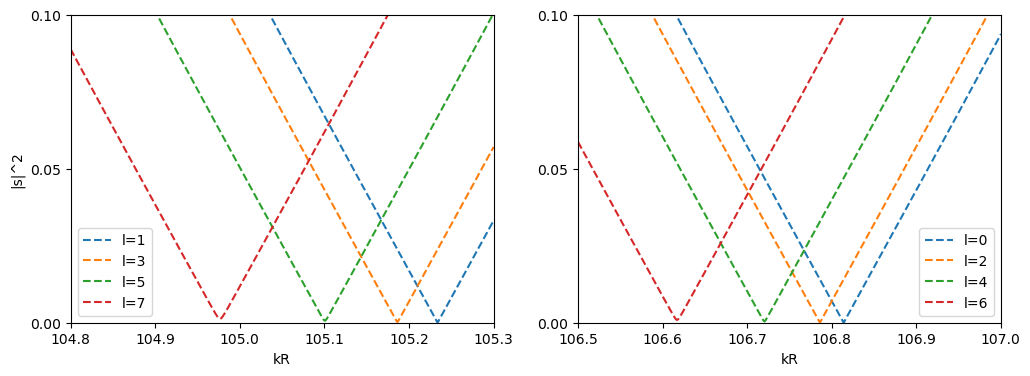

In [121]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for (l_indx, l) in enumerate(l_odd_array):
    ax1.plot(x, sabs_odd_array[l_indx, :], linestyle="dashed", label=f"l={int(l)}")
ax1.set_ylim(0, 0.1)
ax1.set_xlim(104.8, 105.3)
ax1.set_yticks([0, 0.05, 0.1])
ax1.set_xlabel("kR")
ax1.set_ylabel("|s|^2");
ax1.legend()

for (l_indx, l) in enumerate(l_even_array):
    ax2.plot(x, sabs_even_array[l_indx, :], linestyle="dashed", label=f"l={int(l)}")
ax2.set_ylim(0, 0.1)
ax2.set_xlim(106.5, 107)
ax2.set_yticks([0, 0.05, 0.1])
ax2.set_xlabel("kR");
ax2.legend();
#ax2.set_ylabel("|s|^2");